# 04 · Training and evaluation

Trains the flood-onset model on the table from notebook 03 and answers the study's three questions: whether a learned model beats rainfall thresholds, how much skill comes from antecedent conditions alone, and whether skill transfers between flood regimes.

**Input:** notebook 03's `model_table.parquet`.

**Output:** `results_test.csv`, `results_forecast_gap.csv`, `results_transfer.csv`, `test_predictions.parquet`, `flood_model.json`, `fig_results.png`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
)
from xgboost import XGBClassifier

WORK = Path("/kaggle/working")
OUT = WORK / "outputs"
OUT.mkdir(exist_ok=True)

SEED = 0
FEATURES = [
    "rain_1d",
    "rain_3d",
    "rain_7d",
    "rain_14d",
    "rain_30d",
    "rain_api",
    "soil_moisture",
    "soil_change_7d",
    "discharge",
    "discharge_change_3d",
    "discharge_anomaly",
]
RULE_FEATURE = "rain_1d"
RULE_BINS = [0, 64.5, 115.6, 204.5, np.inf]
RULE_LABELS = ["light", "heavy", "very heavy", "extremely heavy"]

PARAMS = {
    "n_estimators": 600,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "eval_metric": "aucpr",
    "early_stopping_rounds": 40,
    "random_state": SEED,
}

In [2]:
table_dir = next(p.parent for p in Path("/kaggle/input").rglob("model_table.parquet"))
table = pd.read_parquet(table_dir / "model_table.parquet")

train = table[table["split"] == "train"]
val = table[table["split"] == "val"]
test = table[table["split"] == "test"]
for name, frame in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: {len(frame)} rows, {frame['target'].sum()} positives ({frame['target'].mean():.2%})")

train: 25776 rows, 253 positives (0.98%)
val: 5706 rows, 179 positives (3.14%)
test: 8247 rows, 236 positives (2.86%)


## Climatology reference

The share of days followed by a flood, by district and calendar month, estimated on the training years. It is the reference every skill score is measured against: a model that cannot beat the local seasonal average has learned nothing useful.

In [3]:
overall_rate = train["target"].mean()
rate_by_month = train.groupby(["district", train["date"].dt.month])["target"].mean().rename("climatology")


def climatology_probability(frame):
    keys = pd.MultiIndex.from_arrays([frame["district"], frame["date"].dt.month])
    return pd.Series(rate_by_month.reindex(keys).to_numpy(), index=frame.index).fillna(overall_rate)


climatology = {name: climatology_probability(frame) for name, frame in [("val", val), ("test", test)]}


def rainfall_bucket(frame):
    return pd.cut(frame[RULE_FEATURE], RULE_BINS, right=False, labels=RULE_LABELS)


rule_rate = train.groupby(rainfall_bucket(train), observed=True)["target"].mean()
rule_rate.round(4)

rain_1d
light              0.0098
heavy              0.0082
very heavy         0.0714
extremely heavy    0.0000
Name: target, dtype: float64

## Metrics

Floods occupy a small fraction of days, so the area under the precision-recall curve describes performance better than ROC area, which is flattered by the abundance of easy negatives. The Brier score measures probability accuracy and its skill form expresses the improvement over climatology.

At a chosen threshold the forecast is judged as warnings are judged operationally: hit rate, false alarm ratio, and the critical success index that combines both. The threshold is chosen on the validation years by maximising the critical success index, never on the test years.

In [4]:
def operating_scores(actual, predicted, threshold):
    flagged = predicted >= threshold
    hits = int((flagged & (actual == 1)).sum())
    false_alarms = int((flagged & (actual == 0)).sum())
    misses = int((~flagged & (actual == 1)).sum())
    return {
        "hit_rate": hits / max(hits + misses, 1),
        "false_alarm_ratio": false_alarms / max(hits + false_alarms, 1),
        "csi": hits / max(hits + misses + false_alarms, 1),
    }


def evaluate(name, actual, predicted, reference, threshold):
    scores = {
        "model": name,
        "pr_auc": average_precision_score(actual, predicted),
        "brier": brier_score_loss(actual, predicted),
        "brier_skill": 1 - brier_score_loss(actual, predicted) / brier_score_loss(actual, reference),
    }
    scores.update(operating_scores(actual, predicted, threshold))
    return scores


def best_threshold(actual, predicted):
    precision, recall, cuts = precision_recall_curve(actual, predicted)
    csi = (precision[:-1] * recall[:-1]) / np.maximum(precision[:-1] + recall[:-1] - precision[:-1] * recall[:-1], 1e-9)
    return float(cuts[int(np.argmax(csi))])

## Model

Gradient-boosted trees with positive-class weighting for the imbalance, early stopping on the validation years, and isotonic calibration fitted on the same years so that a stated probability matches the observed frequency. The validation years therefore serve for stopping, calibration and threshold selection; the test years are untouched until the results below.

In [5]:
def fit(frame, features, validation=None):
    validation = val if validation is None else validation
    positives = frame["target"].sum()
    model = XGBClassifier(**PARAMS, scale_pos_weight=(len(frame) - positives) / positives)
    model.fit(
        frame[features],
        frame["target"],
        eval_set=[(validation[features], validation["target"])],
        verbose=False,
    )
    return model


model = fit(train, FEATURES)
raw_val = model.predict_proba(val[FEATURES])[:, 1]
raw_test = model.predict_proba(test[FEATURES])[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(raw_val, val["target"])
prob_test = calibrator.predict(raw_test)
prob_val = calibrator.predict(raw_val)

print(f"trees used: {model.best_iteration + 1}")

trees used: 14


## Experiment 1: against the baselines

The rainfall rule mirrors the deterministic engine in the WeatherGPT backend, flagging a district when daily rainfall reaches the India Meteorological Department's heavy-rainfall threshold of 64.5 mm.

In [6]:
cut = best_threshold(val["target"], prob_val)
rule_test = rainfall_bucket(test).map(rule_rate).astype(float).fillna(overall_rate)
rule_cut = float(rule_rate.get("heavy", overall_rate))

results = pd.DataFrame(
    [
        evaluate("climatology", test["target"], climatology["test"], climatology["test"], climatology["test"].median()),
        evaluate("rainfall rule", test["target"], rule_test, climatology["test"], rule_cut),
        evaluate("xgboost", test["target"], prob_test, climatology["test"], cut),
    ]
).set_index("model")
results.round(4)

,pr_auc,brier,brier_skill,hit_rate,false_alarm_ratio,csi
model,,,,,,
climatology,0.0380,0.0281,0.0000,0.5932,0.9693,0.0301
rainfall rule,0.0290,0.0281,-0.0008,1.0000,0.9714,0.0286
xgboost,0.0557,0.0275,0.0224,0.1610,0.9176,0.0577


## Experiment 2: the value of a rainfall forecast

The first model sees only conditions observed up to the prediction day. The second additionally sees the rain that actually falls over the next three days, which is an upper bound on what a perfect forecast could contribute. The difference measures how much warning skill is available from catchment state alone, and how much waits on forecast quality.

In [7]:
oracle_features = [*FEATURES, "oracle_rain_next3d"]
oracle_model = fit(train, oracle_features)
oracle_test = oracle_model.predict_proba(test[oracle_features])[:, 1]

gap = pd.DataFrame(
    [
        {"model": "antecedent only", "pr_auc": average_precision_score(test["target"], prob_test)},
        {"model": "perfect rain forecast", "pr_auc": average_precision_score(test["target"], oracle_test)},
    ]
).set_index("model")
gap["share_of_perfect"] = (gap["pr_auc"] / gap["pr_auc"].max()).round(3)
gap.round(4)

,pr_auc,share_of_perfect
model,,
antecedent only,0.0557,0.73
perfect rain forecast,0.0764,1.00


## Experiment 3: transfer between regimes

A model trained on the eastern Ghaghara-Rapti districts is evaluated on the central Ganga-Gomti districts, and the reverse. Because the two groups have different base rates, precision-recall area is reported alongside the base rate it should be read against.

In [8]:
transfer = []
for source in ("east", "central"):
    target_group = "central" if source == "east" else "east"
    trained = fit(train[train["group"] == source], FEATURES, val[val["group"] == source])
    for group in (source, target_group):
        rows = test[test["group"] == group]
        predicted = trained.predict_proba(rows[FEATURES])[:, 1]
        transfer.append(
            {
                "trained_on": source,
                "tested_on": group,
                "pr_auc": average_precision_score(rows["target"], predicted),
                "base_rate": rows["target"].mean(),
            }
        )

transfer = pd.DataFrame(transfer)
transfer["lift_over_base_rate"] = (transfer["pr_auc"] / transfer["base_rate"]).round(2)
transfer.round(4)

,trained_on,tested_on,pr_auc,base_rate,lift_over_base_rate
0,east,east,0.0386,0.0259,1.49
1,east,central,0.0529,0.0314,1.69
2,central,central,0.0730,0.0314,2.33
3,central,east,0.0319,0.0259,1.23


## Shuffled-label control

The same model is trained on training labels shuffled at random. With the link between features and outcome destroyed, test performance must collapse to the base rate; anything better would indicate that information about the outcome reaches the model through the features or the splits rather than through the labels.

In [9]:
shuffled = train.copy()
shuffled["target"] = shuffled["target"].sample(frac=1, random_state=SEED).to_numpy()
control = fit(shuffled, FEATURES)
control_test = control.predict_proba(test[FEATURES])[:, 1]

control_auc = average_precision_score(test["target"], control_test)
print(f"shuffled-label PR-AUC {control_auc:.4f} against a base rate of {test['target'].mean():.4f}")
if control_auc > 2 * test["target"].mean():
    raise AssertionError("shuffled labels still predict floods - features or splits leak")

shuffled-label PR-AUC 0.0408 against a base rate of 0.0286


## Null distribution

One shuffled run is a single draw, so the control above is repeated with independent shuffles of the training and validation labels. The spread of those runs is what this setup scores when no relationship between features and outcome exists, and the observed score is meaningful only if it lies beyond that spread. The reported p-value is the share of shuffled runs that matched or beat the model.

In [10]:
NULL_RUNS = 20


def shuffled_score(seed, features):
    noise_train = train.copy()
    noise_val = val.copy()
    noise_train["target"] = noise_train["target"].sample(frac=1, random_state=seed).to_numpy()
    noise_val["target"] = noise_val["target"].sample(frac=1, random_state=seed + 1000).to_numpy()
    noise_model = fit(noise_train, features, noise_val)
    return average_precision_score(test["target"], noise_model.predict_proba(test[features])[:, 1])


null = pd.Series([shuffled_score(seed, FEATURES) for seed in range(NULL_RUNS)], name="null_pr_auc")
observed = average_precision_score(test["target"], prob_test)
p_value = (int((null >= observed).sum()) + 1) / (NULL_RUNS + 1)

print(f"observed PR-AUC {observed:.4f}")
print(f"null runs: min {null.min():.4f}, median {null.median():.4f}, max {null.max():.4f}")
print(f"p = {p_value:.3f} ({int((null >= observed).sum())} of {NULL_RUNS} shuffled runs matched or beat the model)")

observed PR-AUC 0.0557
null runs: min 0.0225, median 0.0277, max 0.0432
p = 0.048 (0 of 20 shuffled runs matched or beat the model)


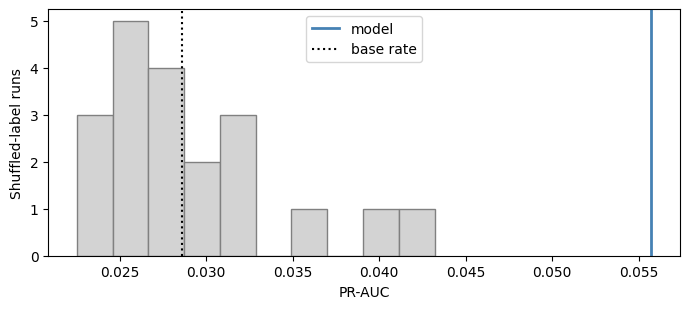

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(null, bins=10, color="lightgrey", edgecolor="grey")
ax.axvline(observed, color="steelblue", linewidth=2, label="model")
ax.axvline(test["target"].mean(), color="black", linestyle=":", label="base rate")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("Shuffled-label runs")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_null_distribution.png", dpi=200)

null.to_frame().assign(observed=observed, p_value=p_value).to_csv(OUT / "results_null.csv", index=False)

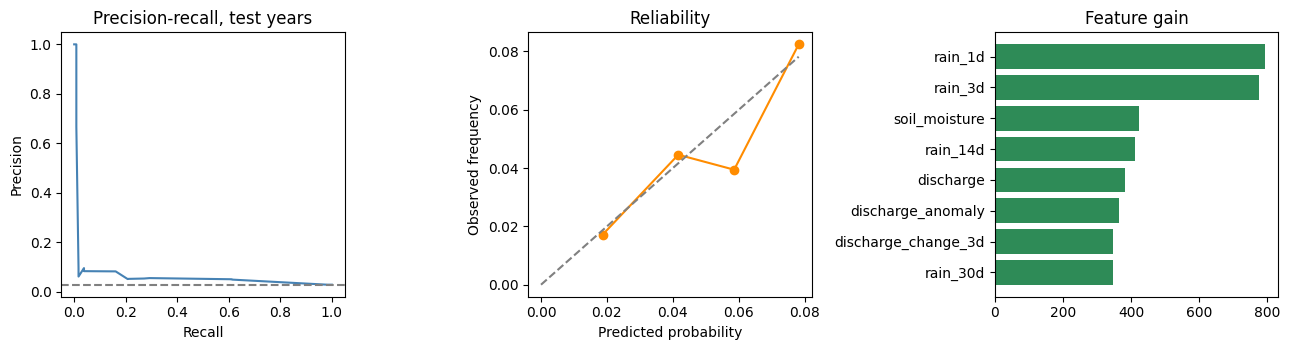

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

precision, recall, _ = precision_recall_curve(test["target"], prob_test)
axes[0].plot(recall, precision, color="steelblue")
axes[0].axhline(test["target"].mean(), color="grey", linestyle="--")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-recall, test years")

observed, expected = calibration_curve(test["target"], prob_test, n_bins=10, strategy="quantile")
axes[1].plot(expected, observed, marker="o", color="darkorange")
axes[1].plot([0, expected.max()], [0, expected.max()], color="grey", linestyle="--")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Observed frequency")
axes[1].set_title("Reliability")

gain = pd.Series(model.get_booster().get_score(importance_type="gain")).sort_values().tail(8)
axes[2].barh(gain.index, gain.to_numpy(), color="seagreen")
axes[2].set_title("Feature gain")

fig.tight_layout()
fig.savefig(OUT / "fig_results.png", dpi=200)

In [13]:
predictions = test[["district", "date", "group", "target"]].copy()
predictions["probability"] = prob_test
predictions["climatology"] = climatology["test"].to_numpy()

results.to_csv(OUT / "results_test.csv")
gap.to_csv(OUT / "results_forecast_gap.csv")
transfer.to_csv(OUT / "results_transfer.csv", index=False)
predictions.to_parquet(OUT / "test_predictions.parquet", index=False)
model.save_model(OUT / "flood_model.json")
sorted(p.name for p in OUT.iterdir())

['fig_null_distribution.png',
 'fig_results.png',
 'flood_model.json',
 'results_forecast_gap.csv',
 'results_null.csv',
 'results_test.csv',
 'results_transfer.csv',
 'test_predictions.parquet']